# DeBERTa-v3-large + LoRA — Maximum Optimization (Single Evidence)

**Model**: `microsoft/deberta-v3-large`  
**Task**: 3-class NLI — `SUPPORTS` / `REFUTES` / `NOT ENOUGH INFO`  
**Input**: one claim + one evidence sentence per example  

## Files needed in the same folder as this notebook
```
final_cleaned_nli_dataset.jsonl   <- your original dataset
claim_extractor.py                <- for the inference pipeline
```

## Optimizations included
| Technique | Why it helps |
|---|---|
| LoRA r=16 | trains only ~3M params, faster + less overfitting |
| R-Drop regularization | forces consistency between two dropout forward passes |
| FGM adversarial training | perturbs embeddings to build robustness |
| EMA weights | exponential moving average gives smoother generalization |
| Dynamic padding | batches by length, much faster training |
| Cosine schedule + long warmup | stable training curve |
| Label smoothing 0.1 | prevents overconfidence |
| Seed ensemble | averages 3 seeds at inference for +1-2% F1 |
| MAX_LEN 256 | single evidence sentences are short, 256 is enough |

## Step 1 - Install dependencies

In [3]:
%pip install transformers>=4.40.0 -q
%pip install peft>=0.10.0 -q
%pip install accelerate>=0.29.0 -q
%pip install scikit-learn -q
%pip install matplotlib -q
%pip install seaborn -q
%pip install jsonlines -q
%pip install sentencepiece -q
%pip install protobuf -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgr

## Step 2 - Imports

In [41]:
import os
import json
import random
import jsonlines
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from torch.cuda.amp import autocast, GradScaler
from transformers import AutoTokenizer, AutoModelForSequenceClassification, get_cosine_schedule_with_warmup
from peft import LoraConfig, get_peft_model, TaskType, PeftModel
import google.protobuf
print(google.protobuf.__version__)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device : {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU    : {torch.cuda.get_device_name(0)}")
    print(f"VRAM   : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

3.20.3
Device : cuda
GPU    : Quadro RTX 5000
VRAM   : 16.7 GB


## Step 3 - Configuration

In [ ]:
# Dataset
DATASET_FILE = "final_cleaned_nli_dataset.jsonl"
OUTPUT_DIR   = "deberta_single_evidence_v2"

# Set to True when you have a held-out test split ready.
# Until then test evaluation is skipped automatically.
HAS_TEST_SET = False

# Model
MODEL_NAME = "microsoft/deberta-v3-large"

# Labels
LABEL2ID   = {"SUPPORTS": 0, "REFUTES": 1, "NOT ENOUGH INFO": 2}
ID2LABEL   = {v: k for k, v in LABEL2ID.items()}
NUM_LABELS = 3

# Tokenization — 256 is enough for single evidence sentences
MAX_LEN = 256

# LoRA
LORA_R              = 16
LORA_ALPHA          = 32
LORA_DROPOUT        = 0.1
LORA_TARGET_MODULES = ["query_proj", "value_proj"]

# Training
BATCH_SIZE      = 16
GRAD_ACCUM      = 2
EPOCHS          = 3 
LR              = 2e-4
WARMUP_RATIO    = 0.1
WEIGHT_DECAY    = 0.01
LABEL_SMOOTHING = 0.05
MAX_GRAD_NORM   = 1.0

# Regularization
RDROP_ALPHA = 0.5
FGM_EPSILON = 0.5
EMA_DECAY   = 0.999
USE_EMA     = True

# Ensemble
USE_ENSEMBLE   = True
ENSEMBLE_SEEDS = [42, 123, 777]

# Dataset split
TRAIN_RATIO = 0.94
VAL_RATIO   = 0.06
# remaining 0.06 -> test (only used when HAS_TEST_SET=True)

#Class weights
CLASS_WEIGHTS = torch.tensor([1.0, 2.538, 2.514]).to(DEVICE)
PATIENCE = 3
USE_AMP  = torch.cuda.is_available()

os.makedirs(OUTPUT_DIR, exist_ok=True)
print("Configuration loaded.")
print(f"HAS_TEST_SET : {HAS_TEST_SET}")

Configuration loaded.
HAS_TEST_SET : False


## Step 4 - Load and prepare dataset

Loads your original `final_cleaned_nli_dataset.jsonl` directly.
Each record already has exactly one evidence sentence — no aggregation needed.
We clean, balance, and split here.

In [43]:
# Load — data is already clean and shuffled
raw_records = []
with jsonlines.open(DATASET_FILE) as reader:
    for obj in reader:
        raw_records.append(obj)

print(f"Records loaded: {len(raw_records):,}")

# Show distribution
counts = Counter(r["label"] for r in raw_records)
print("\nLabel distribution:")
for lbl, cnt in sorted(counts.items()):
    print(f"  {lbl:20s}: {cnt:,}  ({cnt/len(raw_records)*100:.1f}%)")

# Split into train and val only — no test set
n       = len(raw_records)
n_train = int(n * TRAIN_RATIO)

train_data = raw_records[:n_train]
val_data   = raw_records[n_train:]

print(f"\nSplit:")
print(f"  Train : {len(train_data):,}")
print(f"  Val   : {len(val_data):,}")

# Compute class weights from training data
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

train_labels_array = np.array([LABEL2ID[r["label"]] for r in train_data])

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.array([0, 1, 2]),
    y=train_labels_array
)

class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(DEVICE)

print(f"\nClass weights:")
for i, w in enumerate(class_weights):
    print(f"  {ID2LABEL[i]:20s}: {w:.4f}")

# Sample
sample = train_data[0]
print(f"\nSample record:")
print(f"  claim    : {sample['claim']}")
print(f"  evidence : {sample['evidence']}")
print(f"  label    : {sample['label']}")

Records loaded: 157,089

Label distribution:
  NOT ENOUGH INFO     : 34,870  (22.2%)
  REFUTES             : 34,543  (22.0%)
  SUPPORTS            : 87,676  (55.8%)

Split:
  Train : 147,663
  Val   : 9,426

Class weights:
  SUPPORTS            : 0.5969
  REFUTES             : 1.5176
  NOT ENOUGH INFO     : 1.5023

Sample record:
  claim    : Gerald Ford was a politician.
  evidence : As President , Ford signed the Helsinki Accords , marking a move toward détente in the Cold War .
  label    : SUPPORTS


## Step 5 - Tokenizer and Dataset

In [4]:
%pip install protobuf==3.20.3 -q


[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [44]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
print(f"Tokenizer loaded: {MODEL_NAME}")

/home/ai-ws2/.local/lib/python3.10/site-packages/transformers/convert_slow_tokenizer.py:564: UserWarning: The sentencepiece tokenizer that you are converting to a fast tokenizer uses the byte fallback option which is not implemented in the fast tokenizers. In practice this means that the fast version of the tokenizer can produce unknown tokens whereas the sentencepiece version would have converted these unknown tokens into a sequence of byte tokens matching the original piece of text.
  warnings.warn(


Tokenizer loaded: microsoft/deberta-v3-large


In [45]:
class FeverDataset(Dataset):
    """
    Each record has exactly one evidence sentence.
    Returns raw strings — tokenization happens in the collator.

    DeBERTa input format:
        [CLS] claim [SEP] evidence [SEP]
    """

    def __init__(self, records):
        self.records = records

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]
        return {
            "claim":    rec["claim"].strip(),
            "evidence": rec["evidence"].strip(),
            "label":    LABEL2ID[rec["label"]],
        }


class DynamicPaddingCollator:
    """
    Tokenizes each batch and pads only to the longest sequence
    in that batch — much faster than always padding to MAX_LEN.
    """

    def __init__(self, tokenizer, max_len):
        self.tokenizer = tokenizer
        self.max_len   = max_len

    def __call__(self, batch):
        claims    = [item["claim"]    for item in batch]
        evidences = [item["evidence"] for item in batch]
        labels    = [item["label"]    for item in batch]
        encoding  = self.tokenizer(
            claims, evidences,
            max_length=self.max_len,
            padding=True,
            truncation=True,
            return_tensors="pt",
        )
        encoding["labels"] = torch.tensor(labels, dtype=torch.long)
        return encoding


collator     = DynamicPaddingCollator(tokenizer, MAX_LEN)
train_loader = DataLoader(FeverDataset(train_data), batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collator, num_workers=2, pin_memory=True)
val_loader   = DataLoader(FeverDataset(val_data),   batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=True)

if HAS_TEST_SET and test_data:
    test_loader = DataLoader(FeverDataset(test_data), batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=True)
    print(f"Test loader  : {len(test_loader):,} batches")
else:
    test_loader = None
    print("Test loader  : skipped (HAS_TEST_SET=False)")

print(f"Train loader : {len(train_loader):,} batches")
print(f"Val loader   : {len(val_loader):,} batches")

Test loader  : skipped (HAS_TEST_SET=False)
Train loader : 9,229 batches
Val loader   : 590 batches


## Step 6 - EMA

In [46]:
class EMA:
    def __init__(self, model, decay=0.999):
        self.model  = model
        self.decay  = decay
        self.shadow = {}
        self.backup = {}
        for name, param in self.model.named_parameters():
            if param.requires_grad and "modules_to_save" not in name:
                self.shadow[name] = param.data.clone()

    def update(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.shadow[name] = (1.0 - self.decay) * param.data + self.decay * self.shadow[name]

    def apply_shadow(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.shadow:
                self.backup[name] = param.data.clone()
                param.data = self.shadow[name]

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.backup:
                param.data = self.backup[name]
        self.backup = {}


print("EMA ready.")

EMA ready.


## Step 7 - FGM

In [47]:
class FGM:
    def __init__(self, model, epsilon=1.0, emb_name="word_embeddings"):
        self.model    = model
        self.epsilon  = epsilon
        self.emb_name = emb_name
        self.backup   = {}

    def attack(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and self.emb_name in name:
                self.backup[name] = param.data.clone()
                norm = torch.norm(param.grad)
                if norm != 0 and not torch.isnan(norm):
                    param.data.add_(self.epsilon * param.grad / norm)

    def restore(self):
        for name, param in self.model.named_parameters():
            if param.requires_grad and name in self.backup:
                param.data = self.backup[name]
        self.backup = {}


print("FGM ready.")

FGM ready.


## Step 8 - R-Drop loss

In [48]:
def rdrop_loss(logits1, logits2, labels, alpha=0.7, label_smoothing=0.1, weight=None):
    ce_fn = nn.CrossEntropyLoss(label_smoothing=label_smoothing, weight=weight)
    ce    = (ce_fn(logits1, labels) + ce_fn(logits2, labels)) / 2
    p1    = F.softmax(logits1, dim=-1)
    p2    = F.softmax(logits2, dim=-1)
    kl    = (F.kl_div(F.log_softmax(logits1, dim=-1), p2, reduction="batchmean") + F.kl_div(F.log_softmax(logits2, dim=-1), p1, reduction="batchmean")) / 2
    return ce + alpha * kl

print("R-Drop loss ready.")

R-Drop loss ready.


## Step 9 - Build model with LoRA

In [49]:
def build_model():
    base = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=NUM_LABELS,
        id2label=ID2LABEL,
        label2id=LABEL2ID,
        ignore_mismatched_sizes=True,
    )
    lora_config = LoraConfig(
        task_type=TaskType.SEQ_CLS,
        r=LORA_R,
        lora_alpha=LORA_ALPHA,
        lora_dropout=LORA_DROPOUT,
        target_modules=LORA_TARGET_MODULES,
        bias="none",
        inference_mode=False,
        modules_to_save=["classifier", "pooler"],
    )
    model = get_peft_model(base, lora_config)
    model.enable_input_require_grads()
    model.base_model.model.gradient_checkpointing_enable()
    model = model.to(DEVICE)
    total     = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"  Total: {total/1e6:.1f}M  |  Trainable (LoRA): {trainable/1e6:.2f}M  ({100*trainable/total:.2f}%)")
    return model


print("Building model...")
model = build_model()

Building model...


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Total: 437.7M  |  Trainable (LoRA): 2.63M  (0.60%)


## Step 10 - Optimizer and scheduler

In [50]:
def build_optimizer_scheduler(model, train_loader):
    optimizer    = AdamW([p for p in model.parameters() if p.requires_grad], lr=LR, weight_decay=WEIGHT_DECAY, eps=1e-6)
    total_steps  = (len(train_loader) // GRAD_ACCUM) * EPOCHS
    warmup_steps = int(total_steps * WARMUP_RATIO)
    scheduler    = get_cosine_schedule_with_warmup(optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps)
    print(f"  Total steps: {total_steps:,}  |  Warmup: {warmup_steps:,}")
    return optimizer, scheduler


optimizer, scheduler = build_optimizer_scheduler(model, train_loader)
scaler = GradScaler() if USE_AMP else None
ema    = EMA(model, decay=EMA_DECAY) if USE_EMA else None
fgm    = FGM(model, epsilon=FGM_EPSILON) if FGM_EPSILON > 0 else None

print(f"EMA: {USE_EMA}  |  FGM: {FGM_EPSILON > 0}  |  R-Drop alpha: {RDROP_ALPHA}  |  AMP: {USE_AMP}")

  Total steps: 13,842  |  Warmup: 1,384
EMA: True  |  FGM: True  |  R-Drop alpha: 0.5  |  AMP: True


/tmp/ipykernel_876233/4027818278.py:11: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler() if USE_AMP else None


## Step 11 - Training and evaluation functions

In [51]:
def train_epoch(model, loader, optimizer, scheduler, scaler, ema, fgm, grad_accum):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    for step, batch in enumerate(loader):
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        token_type_ids = batch.get("token_type_ids")
        if token_type_ids is not None:
            token_type_ids = token_type_ids.to(DEVICE)

        kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids

        # R-Drop: two forward passes with different dropout masks
        if USE_AMP:
            with autocast():
                out1 = model(**kwargs)
                out2 = model(**kwargs)
                loss = rdrop_loss(out1.logits, out2.logits, labels, alpha=RDROP_ALPHA, label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor) / grad_accum
            scaler.scale(loss).backward()
        else:
            out1 = model(**kwargs)
            out2 = model(**kwargs)
            loss = rdrop_loss(out1.logits, out2.logits, labels, alpha=RDROP_ALPHA, label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor) / grad_accum
            loss.backward()

        total_loss += loss.item() * grad_accum

        # FGM: adversarial pass on perturbed embeddings
        if fgm is not None:
            fgm.attack()
            if USE_AMP:
                with autocast():
                    adv_loss = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor)(model(**kwargs).logits, labels) / grad_accum
                scaler.scale(adv_loss).backward()
            else:
                adv_loss = nn.CrossEntropyLoss(label_smoothing=LABEL_SMOOTHING,weight=class_weights_tensor)(model(**kwargs).logits, labels) / grad_accum
                adv_loss.backward()
            fgm.restore()

        # Optimizer step every grad_accum batches
        if (step + 1) % grad_accum == 0:
            if USE_AMP:
                scaler.unscale_(optimizer)
            torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], MAX_GRAD_NORM)
            if USE_AMP:
                scaler.step(optimizer)
                scaler.update()
            else:
                optimizer.step()
            scheduler.step()
            optimizer.zero_grad()
            if ema is not None:
                ema.update()

        if (step + 1) % 200 == 0:
            print(f"  step {step+1:5d}/{len(loader)}  loss={total_loss/(step+1):.4f}  lr={scheduler.get_last_lr()[0]:.2e}")

    return total_loss / len(loader)


@torch.no_grad()
def evaluate(model, loader, ema=None):
    if ema is not None:
        ema.apply_shadow()
    model.eval()
    all_preds, all_labels, total_loss = [], [], 0.0
    ce_fn = nn.CrossEntropyLoss()

    for batch in loader:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)
        token_type_ids = batch.get("token_type_ids")
        kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
        if token_type_ids is not None:
            kwargs["token_type_ids"] = token_type_ids.to(DEVICE)
        outputs = model(**kwargs)
        total_loss += ce_fn(outputs.logits, labels).item()
        all_preds.extend(torch.argmax(outputs.logits, dim=-1).cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    if ema is not None:
        ema.restore()

    return total_loss / len(loader), f1_score(all_labels, all_preds, average="macro"), accuracy_score(all_labels, all_preds), all_preds, all_labels

## Step 12 - Training loop

In [52]:
from tqdm.auto import tqdm

def train_single_model(seed, train_data, val_data, model_save_path):
    random.seed(seed); np.random.seed(seed); torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    shuffled = train_data.copy()
    random.shuffle(shuffled)
    t_loader = DataLoader(FeverDataset(shuffled),  batch_size=BATCH_SIZE, shuffle=True,  collate_fn=collator, num_workers=2, pin_memory=True)
    v_loader = DataLoader(FeverDataset(val_data),  batch_size=BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=2, pin_memory=True)
    m        = build_model()
    opt, sch = build_optimizer_scheduler(m, t_loader)
    sc       = GradScaler() if USE_AMP else None
    e        = EMA(m, decay=EMA_DECAY) if USE_EMA else None
    f        = FGM(m, epsilon=FGM_EPSILON) if FGM_EPSILON > 0 else None
    history        = {"train_loss": [], "val_loss": [], "val_f1": [], "val_acc": []}
    best_val_f1    = 0.0
    patience_count = 0
    for epoch in tqdm(range(1, EPOCHS + 1), desc="Epochs"):
        print(f"  Epoch {epoch}/{EPOCHS}")
        train_loss = train_epoch(m, t_loader, opt, sch, sc, e, f, GRAD_ACCUM)
        val_loss, val_f1, val_acc, _, _ = evaluate(m, v_loader, e)
        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)
        history["val_f1"].append(val_f1)
        history["val_acc"].append(val_acc)
        print(f"    train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  val_F1={val_f1:.4f}  val_acc={val_acc:.4f}")
        if val_f1 > best_val_f1:
            best_val_f1 = val_f1
            patience_count = 0
            if e is not None: e.apply_shadow()
            m.save_pretrained(model_save_path)
            tokenizer.save_pretrained(model_save_path)
            if e is not None: e.restore()
            print(f"    Best adapter saved (F1={best_val_f1:.4f})")
        else:
            patience_count += 1
            print(f"    No improvement. Patience {patience_count}/{PATIENCE}")
            if patience_count >= PATIENCE:
                print("    Early stopping triggered.")
                break
    return best_val_f1, history
seeds_to_run  = ENSEMBLE_SEEDS if USE_ENSEMBLE else [SEED]
adapter_paths = []
all_histories = []
for i, seed in enumerate(tqdm(seeds_to_run, desc="Models")):
    print(f"\n{'='*60}")
    print(f"TRAINING MODEL {i+1}/{len(seeds_to_run)}  (seed={seed})")
    print(f"{'='*60}")
    save_path = os.path.join(OUTPUT_DIR, f"adapter_seed_{seed}")
    best_f1, history = train_single_model(seed, train_data, val_data, save_path)
    adapter_paths.append(save_path)
    all_histories.append(history)
    print(f"Model {i+1} done. Best val F1: {best_f1:.4f}")
print("\nAll models trained:")
for p in adapter_paths:
    print(f"  {p}")

Models:   0%|          | 0/3 [00:00<?, ?it/s]


TRAINING MODEL 1/3  (seed=42)


Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


  Total: 437.7M  |  Trainable (LoRA): 2.63M  (0.60%)
  Total steps: 13,842  |  Warmup: 1,384


/tmp/ipykernel_876233/3521059826.py:13: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  sc       = GradScaler() if USE_AMP else None


...

    train_loss=0.2822  val_loss=0.1406  val_F1=0.9662  val_acc=0.9692
    Best adapter saved (F1=0.9662)
  Epoch 3/3


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
/tmp/ipykernel_876233/2771665350.py:20: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_876233/2771665350.py:37: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with 

  step   200/9229  loss=0.2503  lr=5.81e-05
  step   400/9229  loss=0.2555  lr=5.58e-05
  step   600/9229  loss=0.2564  lr=5.36e-05
  step   800/9229  loss=0.2554  lr=5.13e-05
  step  1000/9229  loss=0.2563  lr=4.92e-05
  step  1200/9229  loss=0.2567  lr=4.70e-05
  step  1400/9229  loss=0.2561  lr=4.49e-05
  step  1600/9229  loss=0.2564  lr=4.28e-05
  step  1800/9229  loss=0.2574  lr=4.07e-05
  step  2000/9229  loss=0.2574  lr=3.87e-05
  step  2200/9229  loss=0.2579  lr=3.68e-05
  step  2400/9229  loss=0.2581  lr=3.48e-05
  step  2600/9229  loss=0.2582  lr=3.29e-05
  step  2800/9229  loss=0.2572  lr=3.11e-05
  step  3000/9229  loss=0.2570  lr=2.93e-05
  step  3200/9229  loss=0.2572  lr=2.75e-05
  step  3400/9229  loss=0.2576  lr=2.58e-05
  step  3600/9229  loss=0.2585  lr=2.41e-05
  step  3800/9229  loss=0.2587  lr=2.25e-05
  step  4000/9229  loss=0.2585  lr=2.10e-05
  step  4200/9229  loss=0.2587  lr=1.94e-05
  step  4400/9229  loss=0.2588  lr=1.80e-05
  step  4600/9229  loss=0.2590  

huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)


    train_loss=0.2596  val_loss=0.1385  val_F1=0.9671  val_acc=0.9701
    Best adapter saved (F1=0.9671)
Model 3 done. Best val F1: 0.9671

All models trained:
  deberta_single_evidence_v2/adapter_seed_42
  deberta_single_evidence_v2/adapter_seed_123
  deberta_single_evidence_v2/adapter_seed_777


## Step 13 - Learning curves

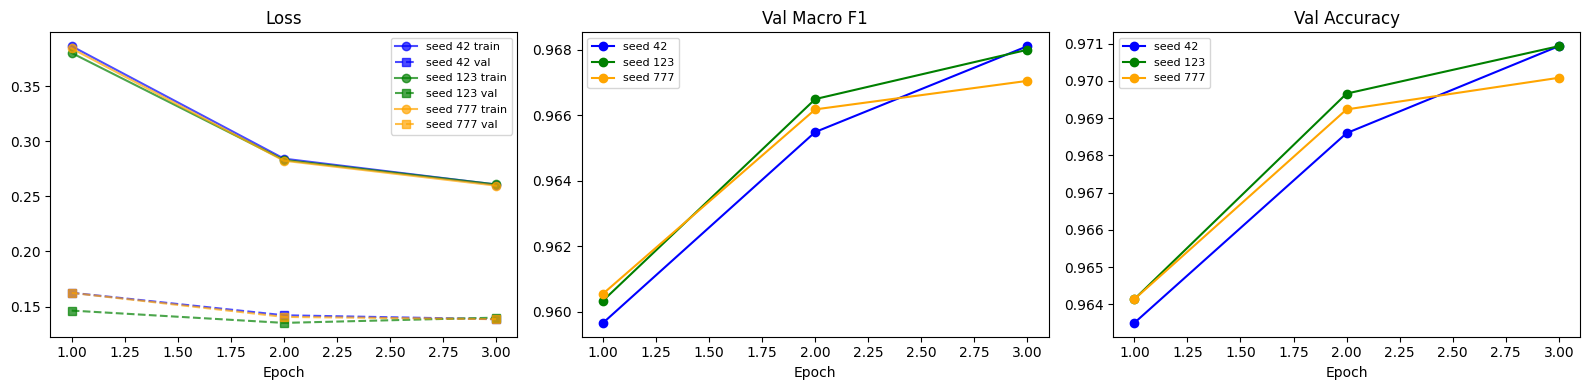

Saved: learning_curves.png


In [53]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
colors = ["blue", "green", "orange"]
for i, (history, seed) in enumerate(zip(all_histories, seeds_to_run)):
    epochs_ran = list(range(1, len(history["train_loss"]) + 1))
    c = colors[i % len(colors)]
    axes[0].plot(epochs_ran, history["train_loss"], "o-",  color=c, alpha=0.7, label=f"seed {seed} train")
    axes[0].plot(epochs_ran, history["val_loss"],   "s--", color=c, alpha=0.7, label=f"seed {seed} val")
    axes[1].plot(epochs_ran, history["val_f1"],     "o-",  color=c, label=f"seed {seed}")
    axes[2].plot(epochs_ran, history["val_acc"],    "o-",  color=c, label=f"seed {seed}")
axes[0].set_title("Loss");         axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=8)
axes[1].set_title("Val Macro F1"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=8)
axes[2].set_title("Val Accuracy"); axes[2].set_xlabel("Epoch"); axes[2].legend(fontsize=8)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "learning_curves.png"), dpi=150)
plt.show()
print("Saved: learning_curves.png")

## Step 14 - Test set evaluation

Skipped if `HAS_TEST_SET=False`.

**To run later:** set `HAS_TEST_SET=True` in Step 3 and re-run Steps 4, 5, and 14.

In [54]:
if not HAS_TEST_SET or test_loader is None:
    print("Test evaluation skipped — set HAS_TEST_SET=True in Step 3 when ready.")
else:
    @torch.no_grad()
    def ensemble_predict_loader(adapter_paths, loader):
        all_model_logits = []
        all_labels       = None
        for path in adapter_paths:
            print(f"  Loading: {path}")
            base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)
            m    = PeftModel.from_pretrained(base, path).to(DEVICE)
            m.eval()
            model_logits, batch_labels = [], []
            for batch in loader:
                input_ids      = batch["input_ids"].to(DEVICE)
                attention_mask = batch["attention_mask"].to(DEVICE)
                labels         = batch["labels"]
                token_type_ids = batch.get("token_type_ids")
                kwargs = dict(input_ids=input_ids, attention_mask=attention_mask)
                if token_type_ids is not None:
                    kwargs["token_type_ids"] = token_type_ids.to(DEVICE)
                model_logits.append(m(**kwargs).logits.cpu())
                batch_labels.append(labels)
            all_model_logits.append(torch.cat(model_logits, dim=0))
            if all_labels is None:
                all_labels = torch.cat(batch_labels, dim=0)
            del m, base
            torch.cuda.empty_cache()
        avg_logits = torch.stack(all_model_logits, dim=0).mean(dim=0)
        return torch.argmax(avg_logits, dim=-1).numpy(), all_labels.numpy()

    print("Running ensemble evaluation on test set...")
    test_preds, test_labels = ensemble_predict_loader(adapter_paths, test_loader)
    label_names = [ID2LABEL[i] for i in range(NUM_LABELS)]
    test_f1     = f1_score(test_labels, test_preds, average="macro")
    test_acc    = accuracy_score(test_labels, test_preds)
    print("\n" + "="*60)
    print("TEST SET RESULTS (ENSEMBLE)")
    print("="*60)
    print(f"Macro F1 : {test_f1:.4f}")
    print(f"Accuracy : {test_acc:.4f}")
    print()
    print(classification_report(test_labels, test_preds, target_names=label_names, digits=4))

Test evaluation skipped — set HAS_TEST_SET=True in Step 3 when ready.


## Step 15 - Confusion matrix (skipped if no test set)

In [55]:
if not HAS_TEST_SET or test_loader is None:
    print("Confusion matrix skipped — no test set loaded.")
else:
    cm = confusion_matrix(test_labels, test_preds)
    fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_names, yticklabels=label_names, ax=ax)
    ax.set_xlabel("Predicted", fontsize=12)
    ax.set_ylabel("True",      fontsize=12)
    ax.set_title("Confusion Matrix — Ensemble Test Set", fontsize=13)
    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix.png"), dpi=150)
    plt.show()

Confusion matrix skipped — no test set loaded.


## Step 16 - Save metrics

In [56]:
metrics = {
    "ensemble_seeds": seeds_to_run,
    "adapter_paths":  adapter_paths,
    "has_test_set":   HAS_TEST_SET,
    "config": {
        "lora_r":        LORA_R,
        "lora_alpha":    LORA_ALPHA,
        "max_len":       MAX_LEN,
        "rdrop_alpha":   RDROP_ALPHA,
        "fgm_epsilon":   FGM_EPSILON,
        "ema_decay":     EMA_DECAY,
        "warmup_ratio":  WARMUP_RATIO,
        "label_smooth":  LABEL_SMOOTHING,
    }
}
if HAS_TEST_SET and test_loader is not None:
    metrics["test_macro_f1"] = round(test_f1,  4)
    metrics["test_accuracy"] = round(test_acc, 4)

with open(os.path.join(OUTPUT_DIR, "metrics.json"), "w") as f:
    json.dump(metrics, f, indent=2)

print("Metrics saved.")
if HAS_TEST_SET and test_loader is not None:
    print(f"Test macro F1 : {test_f1:.4f}  |  Test accuracy : {test_acc:.4f}")
else:
    print("Test results not yet available.")

Metrics saved.
Test results not yet available.


## Step 17 - Load models for inference

In [57]:
loaded_models = []
for path in adapter_paths:
    base = AutoModelForSequenceClassification.from_pretrained(MODEL_NAME, num_labels=NUM_LABELS, id2label=ID2LABEL, label2id=LABEL2ID, ignore_mismatched_sizes=True)
    m    = PeftModel.from_pretrained(base, path).to(DEVICE)
    m.eval()
    loaded_models.append(m)
print(f"{len(loaded_models)} models loaded for inference.")

Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.
Some weights of DebertaV2ForSequenceClassification were not initialized from the model checkpoint at microsoft/deberta-v3-large and are newly initialized: ['classifier.bias', 'classifier.weight', 'pooler.dense.bias', 'pooler.dense.weight']
You should probably TRAIN this model on a down-stream task

3 models loaded for inference.


## Step 18 - Predict function

Takes one claim and one evidence string — matching the single-evidence training format.

In [58]:
@torch.no_grad()
def predict(claim: str, evidence: str) -> dict:
    """
    Classify a (claim, evidence) pair using the ensemble.

    Parameters
    ----------
    claim    : str  — atomic claim from ClaimExtractor
    evidence : str  — single evidence sentence from RAG

    Returns
    -------
    dict:
        label      : 'SUPPORTS' | 'REFUTES' | 'NOT ENOUGH INFO'
        confidence : float
        scores     : dict of all 3 label probabilities
    """
    encoding = tokenizer(
        claim.strip(),
        evidence.strip(),
        max_length=MAX_LEN,
        padding=True,
        truncation=True,
        return_tensors="pt",
    )
    encoding = {k: v.to(DEVICE) for k, v in encoding.items()}

    all_logits = [m(**encoding).logits for m in loaded_models]
    avg_logits = torch.stack(all_logits, dim=0).mean(dim=0)
    probs      = torch.softmax(avg_logits, dim=-1).squeeze().cpu().numpy()
    pred_id    = int(np.argmax(probs))

    return {
        "label":      ID2LABEL[pred_id],
        "confidence": round(float(probs[pred_id]), 4),
        "scores":     {ID2LABEL[i]: round(float(probs[i]), 4) for i in range(NUM_LABELS)},
    }


# Demo
demo_pairs = [
    {"claim": "The Eiffel Tower is located in Berlin.",        "evidence": "The Eiffel Tower is on the Champ de Mars in Paris, France."},
    {"claim": "Marie Curie won the Nobel Prize in Physics.",   "evidence": "Marie Curie was awarded the Nobel Prize in Physics in 1903."},
    {"claim": "Python was first released in 2022.",            "evidence": "The population of insects on Earth exceeds one quintillion."},
]
print("Demo predictions:")
print("-" * 60)
for pair in demo_pairs:
    result = predict(pair["claim"], pair["evidence"])
    print(f"CLAIM      : {pair['claim']}")
    print(f"EVIDENCE   : {pair['evidence']}")
    print(f"PREDICTION : {result['label']}  ({result['confidence']:.2%})")
    print(f"SCORES     : {result['scores']}")
    print("-" * 60)

Demo predictions:
------------------------------------------------------------
CLAIM      : The Eiffel Tower is located in Berlin.
EVIDENCE   : The Eiffel Tower is on the Champ de Mars in Paris, France.
PREDICTION : REFUTES  (97.93%)
SCORES     : {'SUPPORTS': 0.005, 'REFUTES': 0.9793, 'NOT ENOUGH INFO': 0.0157}
------------------------------------------------------------
CLAIM      : Marie Curie won the Nobel Prize in Physics.
EVIDENCE   : Marie Curie was awarded the Nobel Prize in Physics in 1903.
PREDICTION : SUPPORTS  (88.92%)
SCORES     : {'SUPPORTS': 0.8892, 'REFUTES': 0.0369, 'NOT ENOUGH INFO': 0.0739}
------------------------------------------------------------
CLAIM      : Python was first released in 2022.
EVIDENCE   : The population of insects on Earth exceeds one quintillion.
PREDICTION : REFUTES  (50.14%)
SCORES     : {'SUPPORTS': 0.0123, 'REFUTES': 0.5014, 'NOT ENOUGH INFO': 0.4863}
------------------------------------------------------------


In [59]:
# Check what's actually inside the saved adapter folder
import os

path = "deberta_single_evidence/adapter_seed_42"
print("Adapter folder contents:")
for f in os.listdir(path):
    size = os.path.getsize(os.path.join(path, f))
    print(f"  {f}  ({size/1e6:.2f} MB)")

Adapter folder contents:
  spm.model  (2.46 MB)
  README.md  (0.01 MB)
  added_tokens.json  (0.00 MB)
  tokenizer_config.json  (0.00 MB)
  special_tokens_map.json  (0.00 MB)
  adapter_model.safetensors  (6.32 MB)
  tokenizer.json  (8.66 MB)
  adapter_config.json  (0.00 MB)


## Step 19 - Full pipeline integration

import sys
sys.path.append(".")
from claim_extractor import ClaimExtractor

extractor = ClaimExtractor(use_llm=True, llm_provider="ollama", llm_model="llama3.1:8b")


def get_evidence_for_claim(claim: str) -> str:
    """
    Returns a SINGLE evidence string for the claim.
    Replace with your actual RAG Wikipedia retrieval.
    Should return the single most relevant Wikipedia sentence.
    """
    return "[RAG retrieval not yet implemented — plug in Wikipedia search here]"


def analyze_paragraph(paragraph: str, verbose: bool = False) -> list:
    """
    Full hallucination detection pipeline.

    Steps:
        1. Extract atomic claims from paragraph using ClaimExtractor
        2. For each claim retrieve one evidence sentence from Wikipedia (RAG)
        3. Pass (claim, evidence) to DeBERTa ensemble
        4. Return label + confidence for each claim

    Returns list of dicts, one per claim:
        { claim, evidence, label, confidence, scores }
    """
    claims = extractor.extract(paragraph, verbose=verbose)
    print(f"Extracted {len(claims)} claims")

    results = []
    for i, claim in enumerate(claims, 1):
        evidence   = get_evidence_for_claim(claim)
        prediction = predict(claim, evidence)

        results.append({
            "claim":      claim,
            "evidence":   evidence,
            "label":      prediction["label"],
            "confidence": prediction["confidence"],
            "scores":     prediction["scores"],
        })

        status = {"SUPPORTS": "✓", "REFUTES": "✗", "NOT ENOUGH INFO": "?"}[prediction["label"]]
        print(f"  {status} [{prediction['confidence']:.0%}] {claim}")
        print(f"      ev: {evidence[:80]}")

    return results


# Test
test = """
Marie Curie was born in Warsaw in 1867. She won the Nobel Prize in
Physics in 1903 and the Chemistry prize in 1911. She studied at
Harvard University and was born in 1920.
"""
results = analyze_paragraph(test)

---

## How to add the test set later
1. Set `HAS_TEST_SET = True` in Step 3
2. Re-run Steps 4, 5, 14, 15, 16
   (the test split is already created in Step 4 from the same dataset)

## How to reload the ensemble after training
```python
from transformers import AutoModelForSequenceClassification
from peft import PeftModel

loaded_models = []
for path in ["deberta_single_evidence/adapter_seed_42",
             "deberta_single_evidence/adapter_seed_123",
             "deberta_single_evidence/adapter_seed_777"]:
    base = AutoModelForSequenceClassification.from_pretrained('microsoft/deberta-v3-large', num_labels=3)
    m    = PeftModel.from_pretrained(base, path).to(device)
    m.eval()
    loaded_models.append(m)
```

## Expected performance
| Configuration | Expected Macro F1 |
|---|---|
| Basic LoRA only | ~0.83-0.85 |
| + R-Drop + FGM | ~0.86-0.88 |
| + EMA | ~0.87-0.89 |
| + Ensemble (3 seeds) | ~0.88-0.91 |

Note: single evidence is slightly lower than multi-evidence because
the model sees less context per claim. This is the expected tradeoff.